Dataset Loaded Successfully!
   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB

Summary Statistics:
       Unnamed: 0          TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   

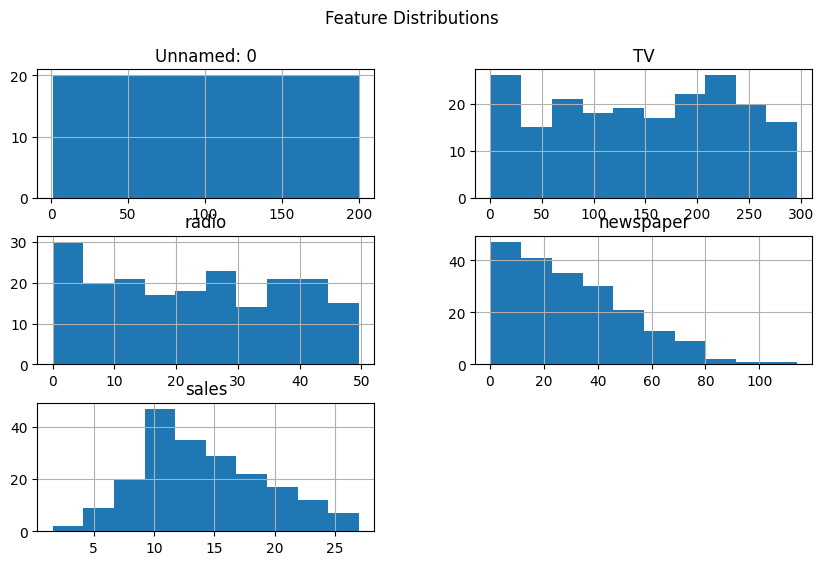

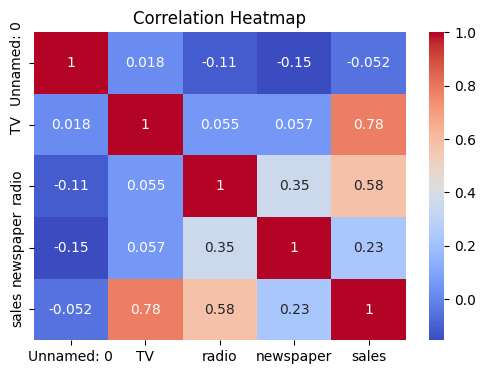

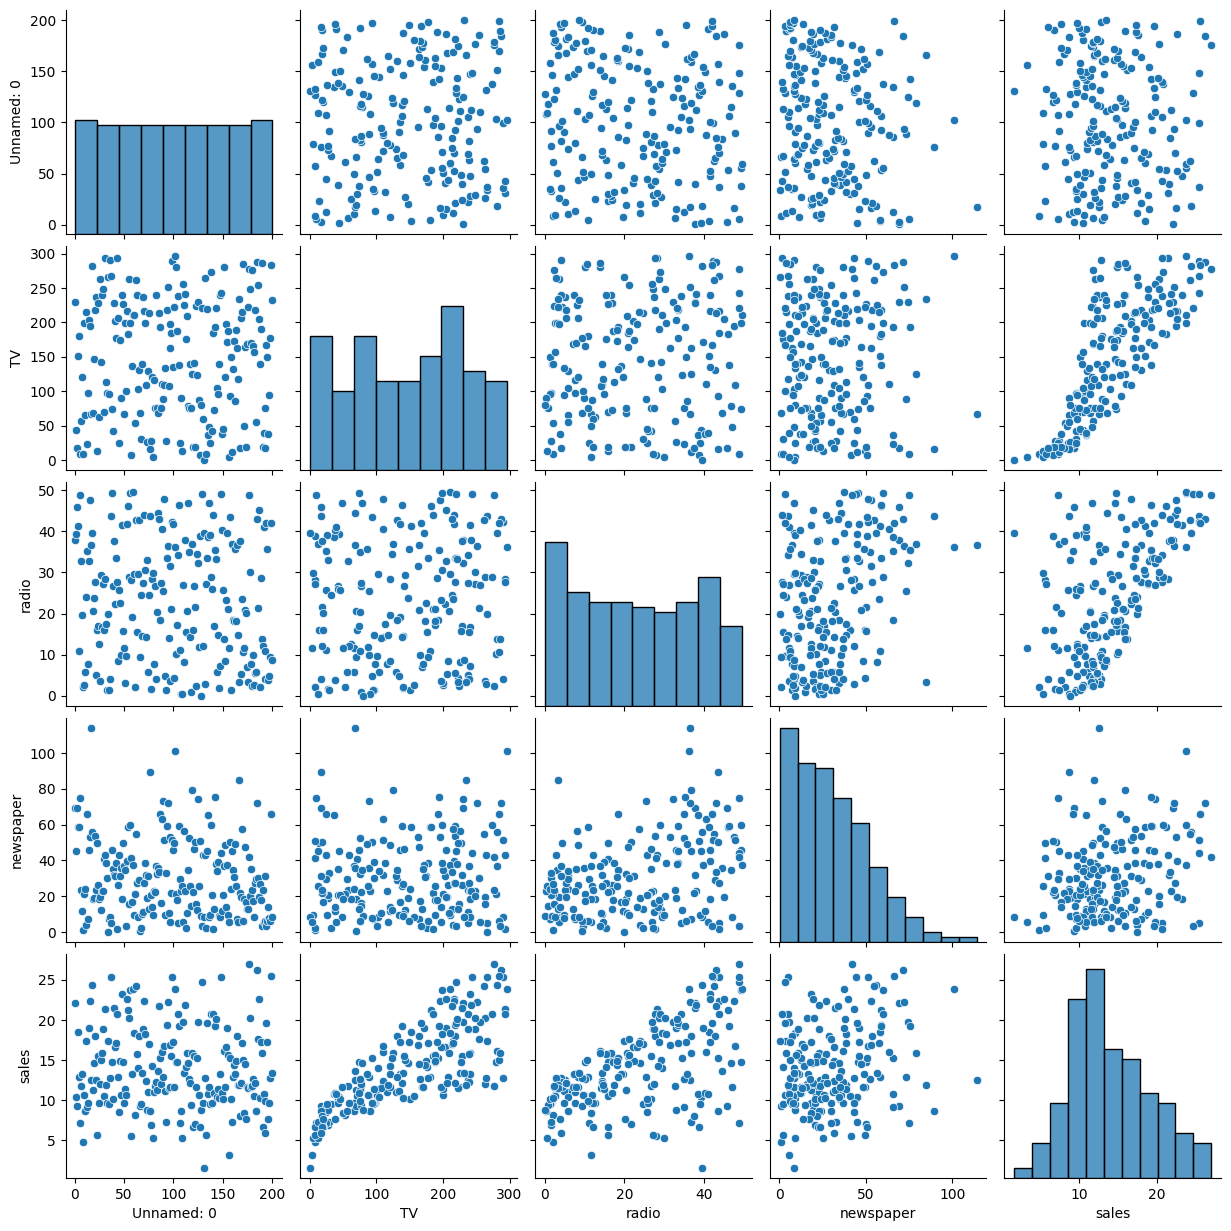


Model Trained Successfully!

Sample Predictions:
     Actual  Predicted
95     16.9  16.408024
15     22.4  20.889882
30     21.4  21.553843
158     7.3  10.608503
128    24.7  22.112373

Model Evaluation:
MSE: 3.1740973539761033
RMSE: 1.78159966153345
R² Score: 0.899438024100912


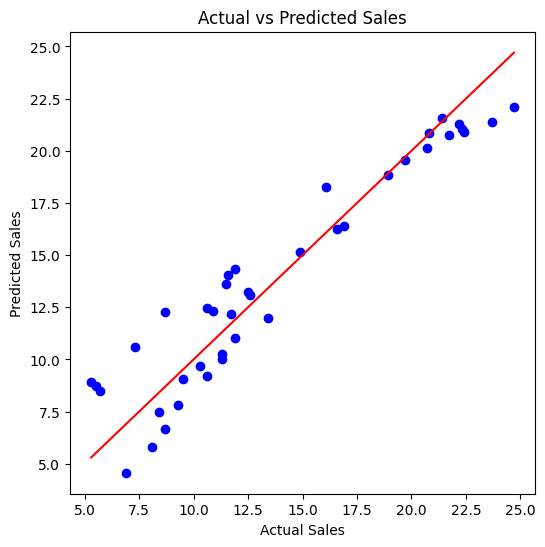

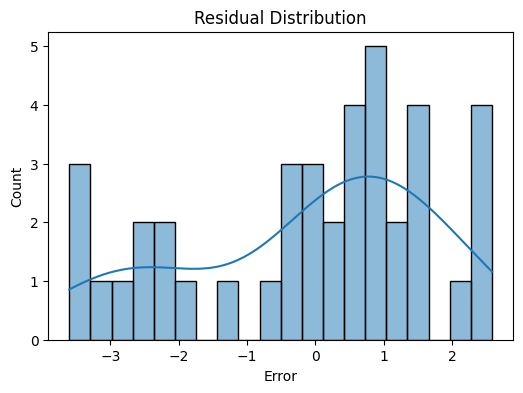


Manual Prediction Example
Input: [[230.   37.8  69.2]]
Predicted Sales: 20.609498518409428


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================
# DA_MiniProject_TeamX.
# ============================================

# Team Members:
# 1. Partiyush Thakur - 2410992555
# 2. Nitin Sharma     - 2410992551
# 3. Tushar Sharma    - 2410992573

# Project Title: Predicting Sales Using Linear Regression
# Dataset: Advertising.csv


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)

print("Dataset Loaded Successfully!")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isna().sum())


df.hist(figsize=(10, 6))
plt.suptitle("Feature Distributions")
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df)
plt.show()

df = df.drop(columns=['Unnamed: 0'])

X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Trained Successfully!")


y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nSample Predictions:")
print(results.head())

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red'
)
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=20)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

sample_input = np.array([[230, 37.8, 69.2]])  # [TV, radio, newspaper]
result = model.predict(sample_input)

print("\nManual Prediction Example")
print("Input:", sample_input)
print("Predicted Sales:", result[0])


